<a href="https://colab.research.google.com/github/PrashVenga/AMLDM/blob/AMLDM-Phase-2/Copy_of_Copy_of_Untitled9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **1. Introduction and Data Setup**
In this section, we initialize the analysis environment by importing the necessary Python libraries for data manipulation (`pandas`, `numpy`) and visualization (`matplotlib`, `seaborn`).

We then load the dataset **"AI Impact on Jobs 2030"**. This dataset contains **3,000 records** across various job titles, detailing factors such as:
* **AI Exposure Index:** How much a job is exposed to AI technologies.
* **Automation Probability:** The likelihood of the job being automated by 2030.
* **Demographics:** Education level, salary, and years of experience.

The goal of this step is to verify the data structure, check for any missing values that might skew the analysis, and preview the first few rows to understand the variables we are working with.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# DATA LOADING -
file_path = '/content/drive/MyDrive/AI_Impact_on_Jobs_2030.csv'
df = pd.read_csv(file_path)

print("--- Dataset Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())

display(df.head())

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Job_Title                    3000 non-null   object 
 1   Average_Salary               3000 non-null   int64  
 2   Years_Experience             3000 non-null   int64  
 3   Education_Level              3000 non-null   object 
 4   AI_Exposure_Index            3000 non-null   float64
 5   Tech_Growth_Factor           3000 non-null   float64
 6   Automation_Probability_2030  3000 non-null   float64
 7   Risk_Category                3000 non-null   object 
 8   Skill_1                      3000 non-null   float64
 9   Skill_2                      3000 non-null   float64
 10  Skill_3                      3000 non-null   float64
 11  Skill_4                      3000 non-null   float64
 12  Skill_5                      3000 non-null   float64
 1

,Job_Title,Average_Salary,Years_Experience,Education_Level,AI_Exposure_Index,Tech_Growth_Factor,Automation_Probability_2030,Risk_Category,Skill_1,Skill_2,Skill_3,Skill_4,Skill_5,Skill_6,Skill_7,Skill_8,Skill_9,Skill_10
0,Security Guard,45795,28,Master's,0.18,1.28,0.85,High,0.45,0.10,0.46,0.33,0.14,0.65,0.06,0.72,0.94,0.00
1,Research Scientist,133355,20,PhD,0.62,1.11,0.05,Low,0.02,0.52,0.40,0.05,0.97,0.23,0.09,0.62,0.38,0.98
2,Construction Worker,146216,2,High School,0.86,1.18,0.81,High,0.01,0.94,0.56,0.39,0.02,0.23,0.24,0.68,0.61,0.83
3,Software Engineer,136530,13,PhD,0.39,0.68,0.60,Medium,0.43,0.21,0.57,0.03,0.84,0.45,0.40,0.93,0.73,0.33
4,Financial Analyst,70397,22,High School,0.52,1.46,0.64,Medium,0.75,0.54,0.59,0.97,0.61,0.28,0.30,0.17,0.02,0.42


In [3]:
# This generates a table of count, mean, std, min, max
summary_table = df[['Average_Salary', 'Years_Experience', 'Automation_Probability_2030', 'AI_Exposure_Index']].describe()
display(summary_table.round(2))

,Average_Salary,Years_Experience,Automation_Probability_2030,AI_Exposure_Index
count,3000.00,3000.00,3000.00,3000.00
mean,89372.28,14.68,0.50,0.50
std,34608.09,8.74,0.25,0.28
min,30030.00,0.00,0.05,0.00
25%,58640.00,7.00,0.31,0.26
50%,89318.00,15.00,0.50,0.50
75%,119086.50,22.00,0.70,0.74
max,149798.00,29.00,0.95,1.00


# **2. Univariate Analysis: The Landscape of Automation**
Before looking at relationships between variables, we must understand the distribution of our primary target variable: **`Automation_Probability_2030`**.

The histogram below helps us answer the question: **"Is the workforce generally safe, or is there a high risk of automation across the board?"**

* **Left-skewed distribution** (tall bars on the right) would indicate many jobs are at high risk.
* **Right-skewed distribution** (tall bars on the left) would suggest most jobs are relatively safe.
* **Bimodal distribution** (two peaks) could suggest a divided economy with very safe and very risky jobs, but few in the middle.

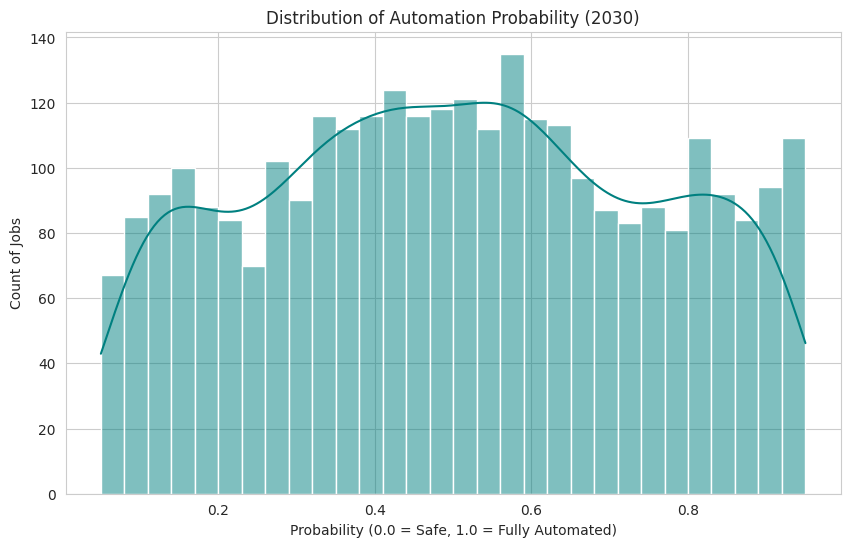

In [4]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Automation_Probability_2030'], kde=True, color='teal', bins=30)
plt.title("Distribution of Automation Probability (2030)")
plt.xlabel("Probability (0.0 = Safe, 1.0 = Fully Automated)")
plt.ylabel("Count of Jobs")
plt.show()

# **3. Bivariate Analysis: Does Education Offer Protection?**
A common assumption is that higher education levels (like a Master's or PhD) provide a "shield" against job automation. We test this hypothesis using a **Boxplot**.

This visualization compares the **`Automation_Probability_2030`** (y-axis) across different **`Education_Level`** categories (x-axis).

**What to look for:**
* **The Median line:** The line inside the box shows the typical risk for that education level. If the line is lower for PhDs than High School graduates, it supports the hypothesis.
* **The Box size:** This shows the variance. A taller box means risk levels vary wildly within that education group; a shorter box means the risk is consistent.

/tmp/ipython-input-1551187206.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Education_Level', y='Automation_Probability_2030', data=df, palette="Set2")


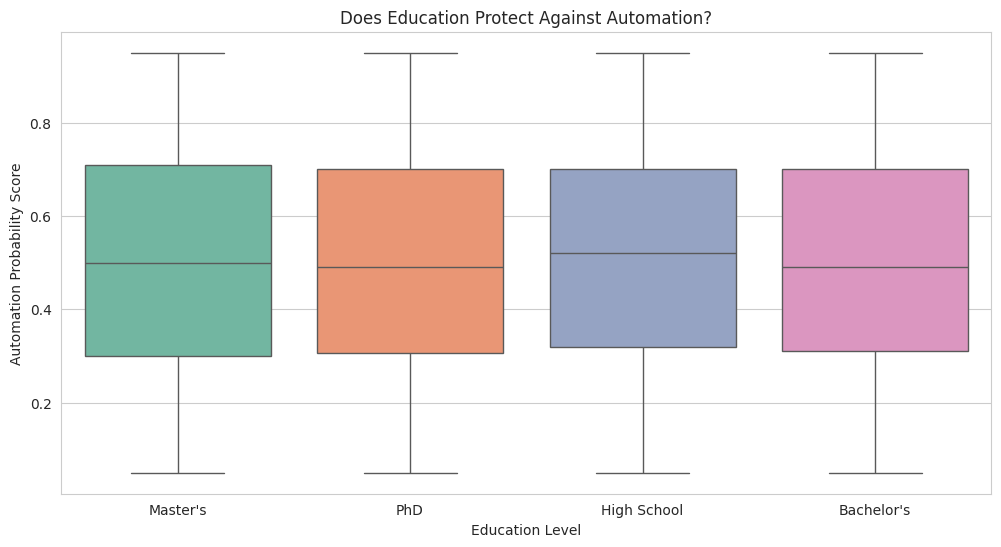

In [5]:
plt.figure(figsize=(12, 6))
# Comparing 'Education_Level' vs 'Automation_Probability_2030'
sns.boxplot(x='Education_Level', y='Automation_Probability_2030', data=df, palette="Set2")
plt.title("Does Education Protect Against Automation?")
plt.xlabel("Education Level")
plt.ylabel("Automation Probability Score")
plt.show()

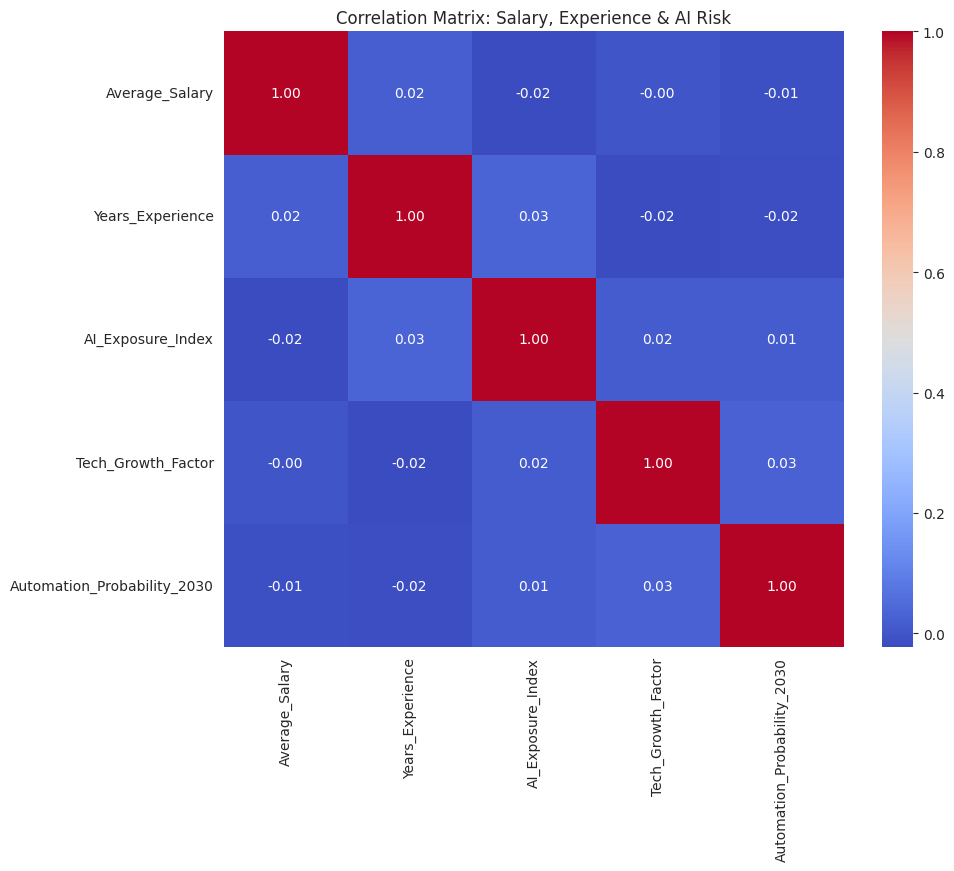

In [6]:
cols_to_correlate = ['Average_Salary', 'Years_Experience', 'AI_Exposure_Index',
                     'Tech_Growth_Factor', 'Automation_Probability_2030']
plt.figure(figsize=(10, 8))
sns.heatmap(df[cols_to_correlate].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix: Salary, Experience & AI Risk")
plt.show()

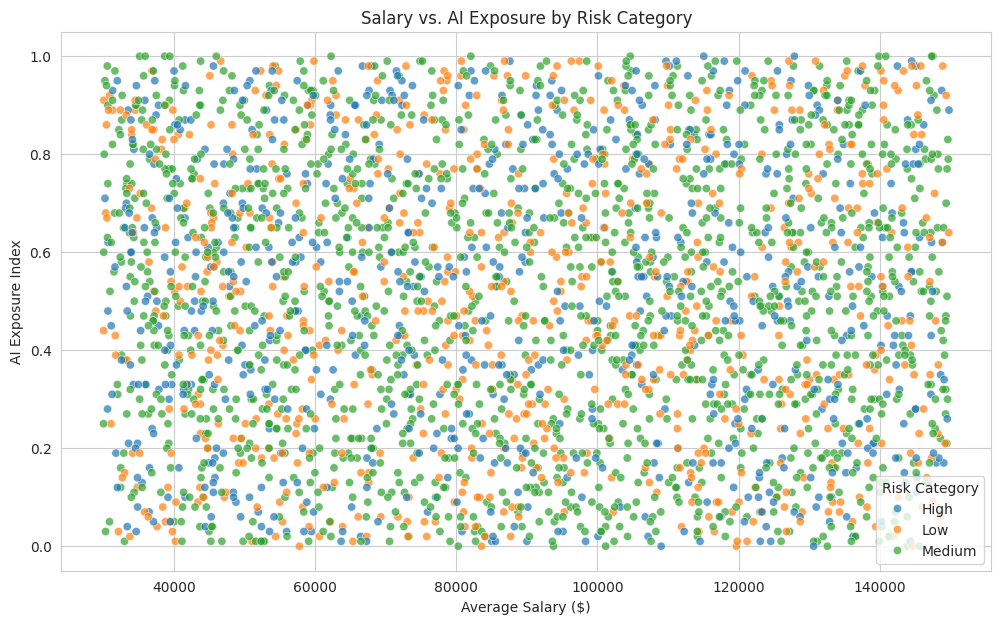

In [7]:
plt.figure(figsize=(12, 7))
sns.scatterplot(
    x='Average_Salary',
    y='AI_Exposure_Index',
    hue='Risk_Category',
    data=df,
    alpha=0.7
)
plt.title("Salary vs. AI Exposure by Risk Category")
plt.xlabel("Average Salary ($)")
plt.ylabel("AI Exposure Index")
plt.legend(title='Risk Category')
plt.show()